## 1. Data Loading and Initial Exploration

First, let's load the dataset from the uploaded CSV file and inspect its structure.

In [3]:
import pandas as pd

# Load the dataset from the local path
df = pd.read_csv('/content/Crop Recommendation dataset.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display information about the dataset (data types, non-null values)
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Descriptive Statistics:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 2. Data Preprocessing

Before training the models, we need to preprocess the data. This involves:
1.  Separating features (X) and target (y).
2.  Encoding the categorical target variable (crop labels).
3.  Splitting the data into training and testing sets.
4.  Scaling the numerical features to ensure all features contribute equally to the model training.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate features (X) and target (y)
X = df.drop('label', axis=1)  # Features are all columns except 'label'
y = df['label']  # Target is the 'label' column

# Encode the target variable (crop names) into numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete. Shapes of training and testing sets:")
print(f"X_train_scaled: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}, y_test: {y_test.shape}")

Data preprocessing complete. Shapes of training and testing sets:
X_train_scaled: (1760, 7), y_train: (1760,)
X_test_scaled: (440, 7), y_test: (440,)


## 3. Model Training and Evaluation

Now, let's train and evaluate the requested machine learning models.

*   **Linear Regression** is typically used for *regression* tasks (predicting continuous values), while crop recommendation is a *classification* task (predicting a category). Therefore, **Logistic Regression** is the appropriate linear model for this problem. I will implement Logistic Regression here.

*   I will also implement **Decision Trees** and **Random Forest Classifiers**, which are well-suited for classification.

### a) Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Evaluate the model
print("--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=le.classes_))
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_log_reg), index=le.classes_, columns=le.classes_))

--- Logistic Regression Performance ---
Accuracy: 0.9636363636363636

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.0

,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
banana,0,21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chickpea,0,0,0,26,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,27,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,17,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,17,0,0,0,...,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,14,0,0,...,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,1,0,0,20,0,...,0,0,0,0,0,1,0,0,1,0
kidneybeans,0,0,0,0,0,0,0,0,0,19,...,0,0,0,0,0,0,1,0,0,0


### b) Decision Tree Classifier

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model
print("--- Decision Tree Classifier Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_dt), index=le.classes_, columns=le.classes_))

--- Decision Tree Classifier Performance ---
Accuracy: 0.9863636363636363

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00    

,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
banana,0,21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,20,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chickpea,0,0,0,26,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,27,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,17,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,17,0,0,0,...,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,14,0,0,...,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,0,0,0,22,0,...,0,0,0,0,0,0,0,0,1,0
kidneybeans,0,0,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,0


### c) Random Forest Classifier

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
print("--- Random Forest Classifier Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf), index=le.classes_, columns=le.classes_))

--- Random Forest Classifier Performance ---
Accuracy: 0.9931818181818182

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00    

,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
banana,0,21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,20,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chickpea,0,0,0,26,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,27,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,17,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,17,0,0,0,...,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,14,0,0,...,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,0,0,0,23,0,...,0,0,0,0,0,0,0,0,0,0
kidneybeans,0,0,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,0


## 4. Model Visualization and Insights

Let's visualize the model performance and gain insights from the Random Forest Classifier.

### a) Accuracy Comparison Graph

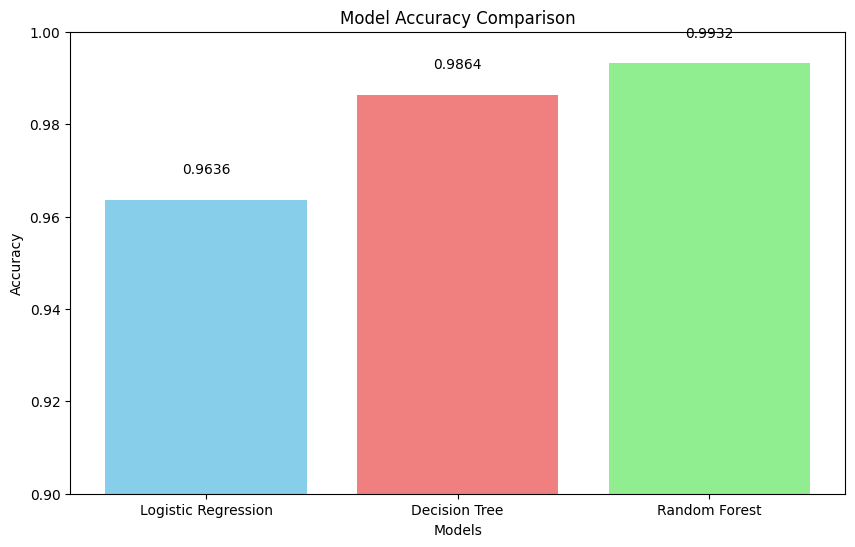

In [8]:
import matplotlib.pyplot as plt

# Store accuracies using the scaled test data and the trained models
acc_log = accuracy_score(y_test, log_reg_model.predict(X_test_scaled))
acc_dt = accuracy_score(y_test, dt_model.predict(X_test_scaled))
acc_rf = accuracy_score(y_test, rf_model.predict(X_test_scaled))

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [acc_log, acc_dt, acc_rf]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0) # Set y-axis limit for better comparison of high accuracies
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom')
plt.show()

### b) Confusion Matrix (for Random Forest - the best performing model)

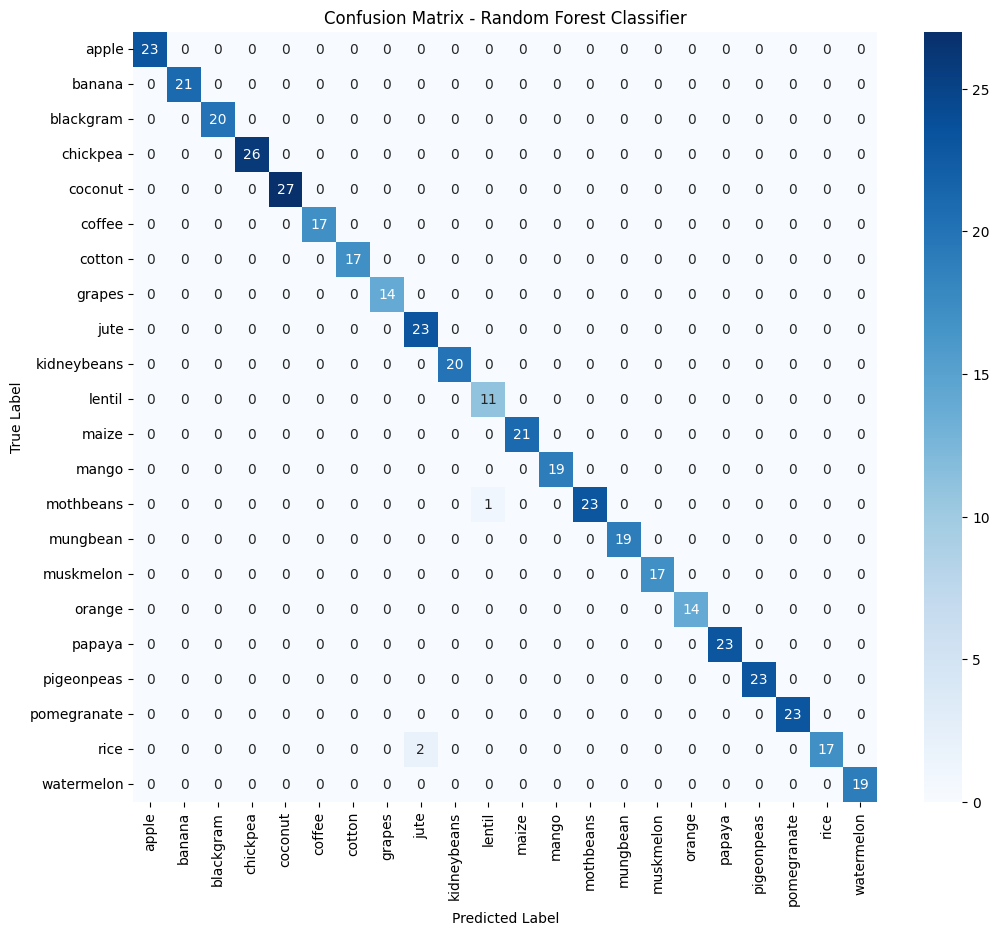

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for the Random Forest model
cm = confusion_matrix(y_test, rf_model.predict(X_test_scaled))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### c) Feature Importance Graph (Random Forest)

/tmp/ipykernel_15182/1175529193.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


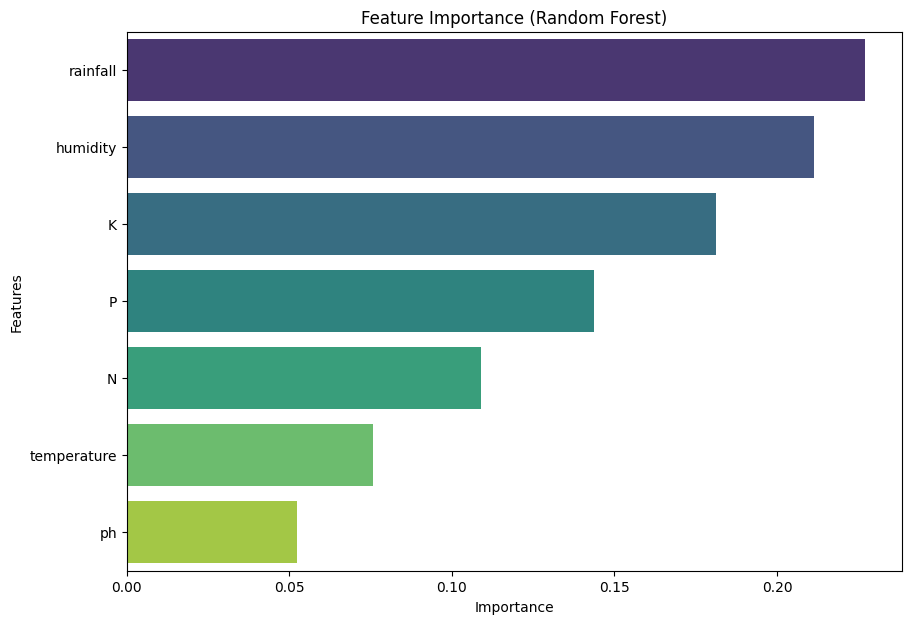

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the Random Forest model
importance = rf_model.feature_importances_
features = X.columns # Get feature names from the original DataFrame X

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

### d) Linear Regression Error Graph (Explanation)

As explained earlier, Linear Regression is designed for predicting continuous numerical values, not categorical classes. In this crop recommendation task, the target variable ('label') is categorical. Therefore, a standard Linear Regression model (`lr`) was not implemented, and an 'error graph' in the context of classification wouldn't be meaningful in the same way it would be for a regression problem (e.g., comparing predicted vs. actual continuous values).

Logistic Regression was used instead as the appropriate linear model for classification.

### e) BONUS: Pairplot (Data visualization)

<Figure size 1500x1500 with 0 Axes>

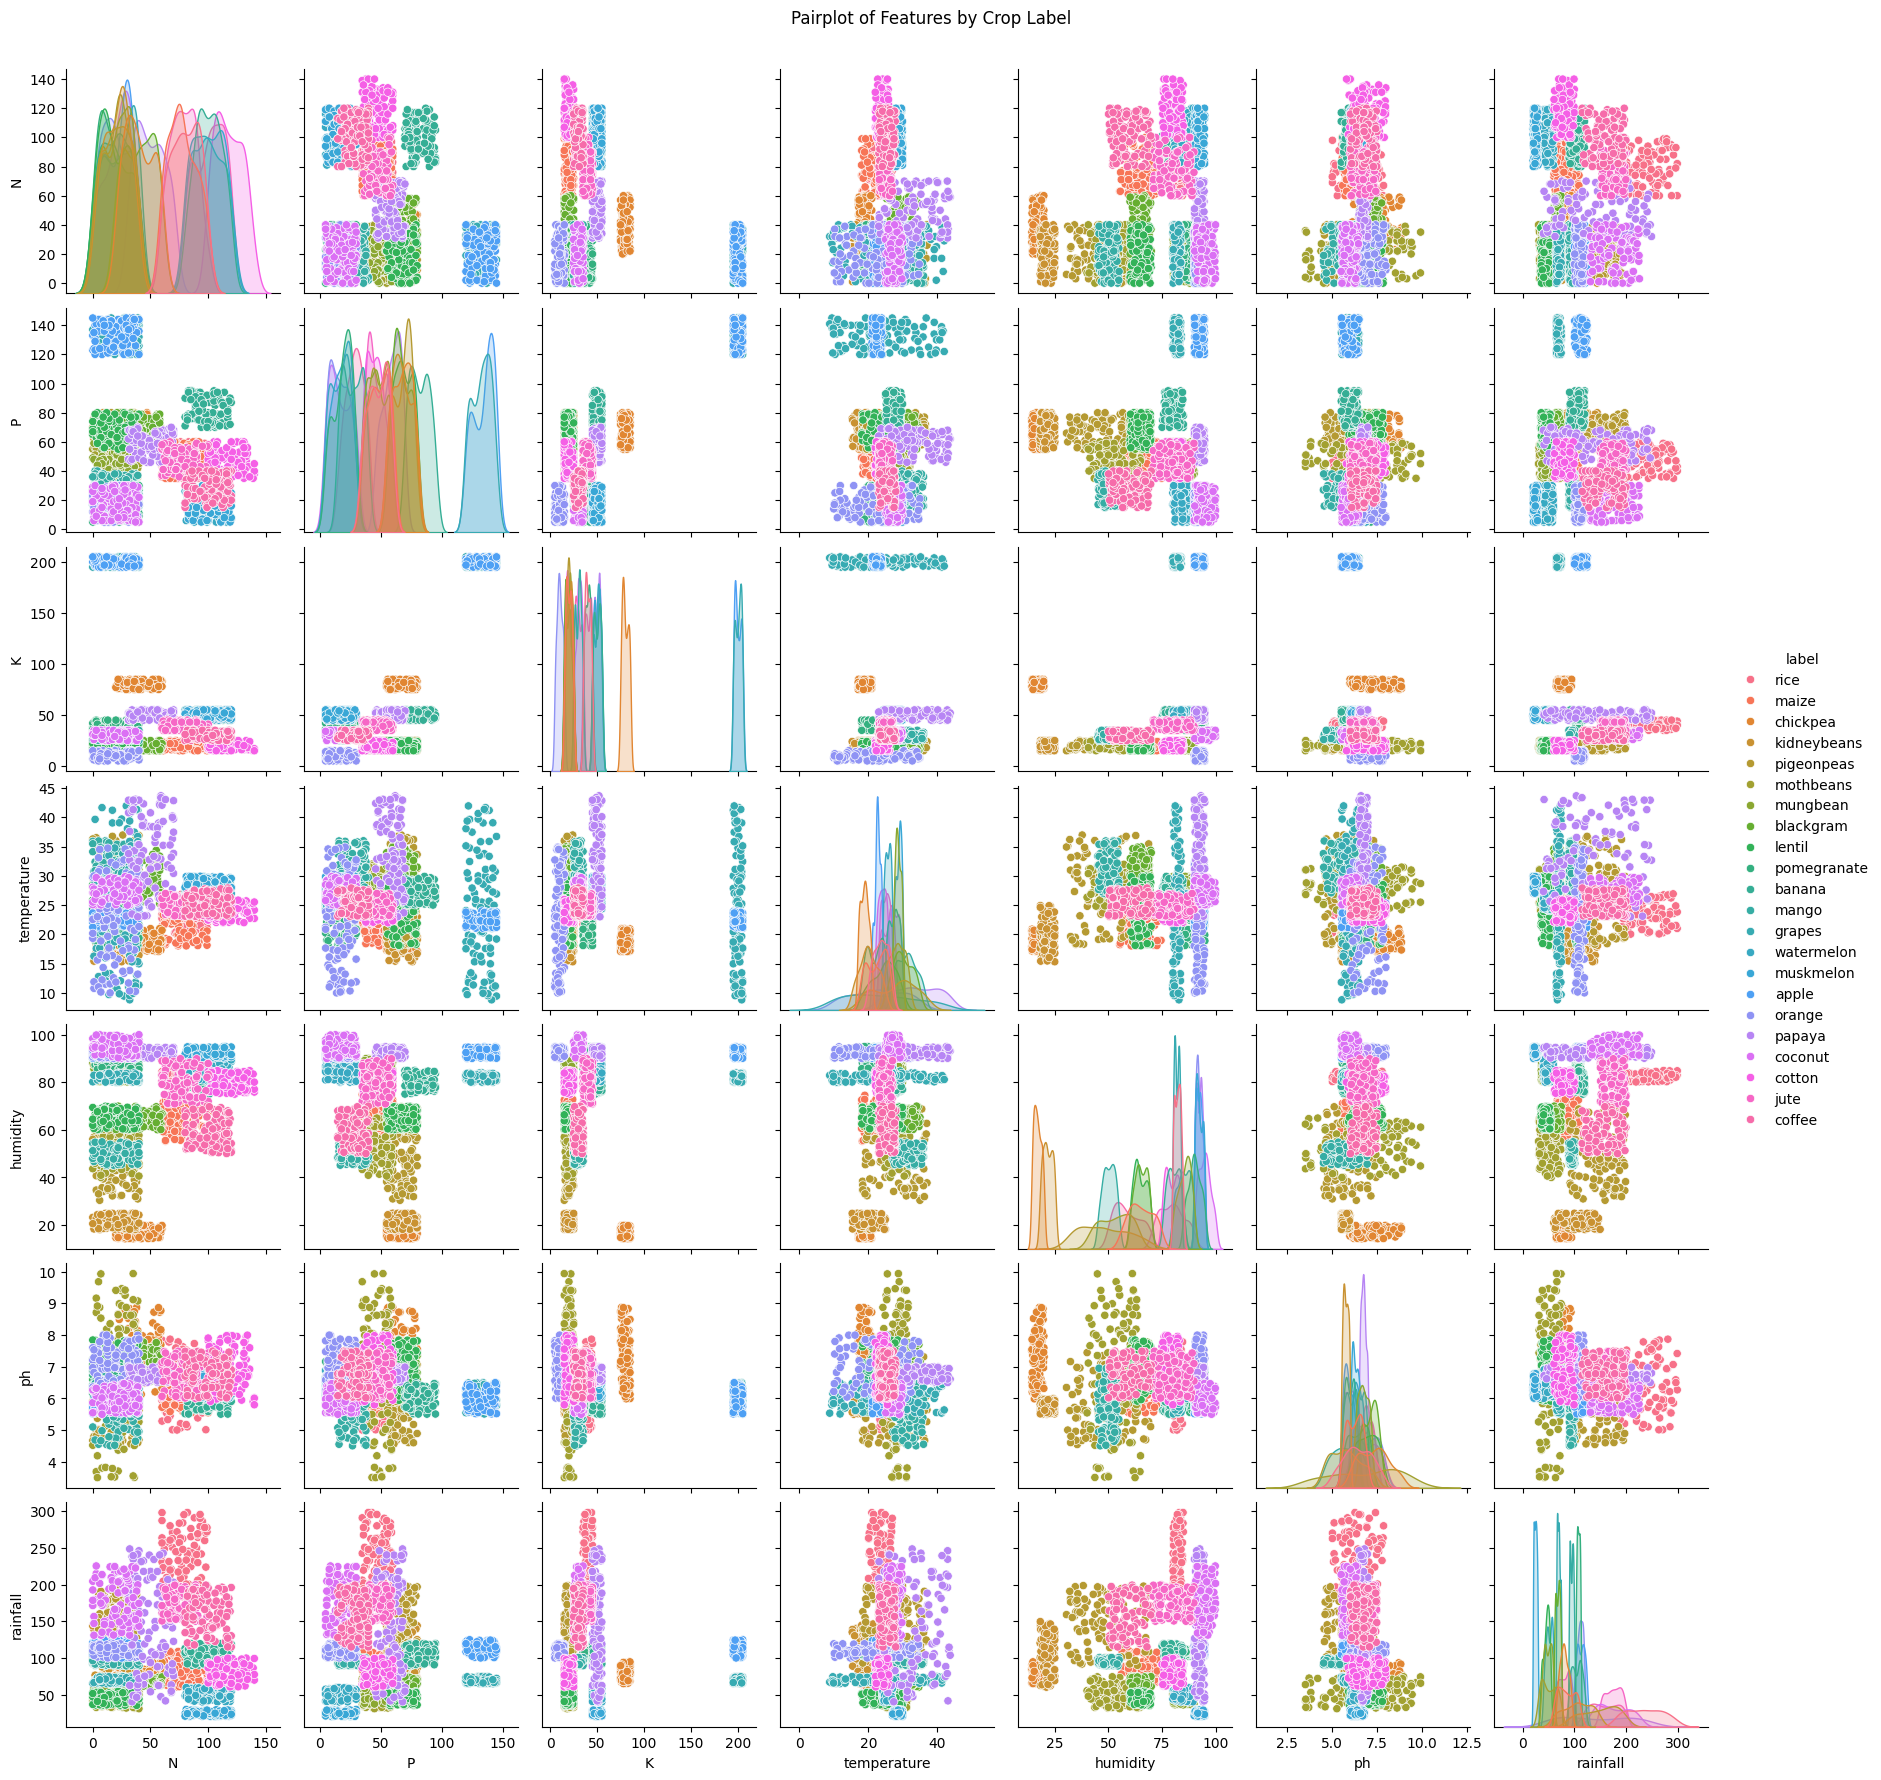

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# This can take some time to generate for larger datasets
plt.figure(figsize=(15, 15))
sns.pairplot(df, hue='label', diag_kind='kde')
plt.suptitle('Pairplot of Features by Crop Label', y=1.02) # Adjust suptitle position
plt.show()